In [10]:
import kagglehub
path = kagglehub.dataset_download("zhijinzhai/loandata")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loandata' dataset.
Path to dataset files: /kaggle/input/loandata


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## Load Dataset

In [4]:
# Find and load the CSV file from the downloaded dataset

df = pd.read_csv(os.path.join(path, "Loan payments data.csv"))
print("Shape:", df.shape)
df.head()


Shape: (500, 11)


,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender
0,xqd20166231,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male
1,xqd20168902,PAIDOFF,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female
2,xqd20160003,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female
3,xqd20160004,PAIDOFF,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male
4,xqd20160005,PAIDOFF,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female


## Task 1: Identify Data Quality Issues

In [5]:
# 1.1 Check data types
df.dtypes


,0
Loan_ID,object
loan_status,object
Principal,int64
terms,int64
effective_date,object
due_date,object
paid_off_time,object
past_due_days,float64
age,int64
education,object


In [6]:
# 1.2 Check missing values per column
missing = df.isna().sum()
missing_pct = (df.isna().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report[missing_report['Missing Count'] > 0]


,Missing Count,Missing %
paid_off_time,100,20.0
past_due_days,300,60.0


In [7]:
# 1.3 Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [8]:
# 1.4 Summary statistics to spot anomalies (unexpected min/max values)
df.describe()


,Principal,terms,past_due_days,age
count,500.000000,500.000000,200.00000,500.000000
mean,943.200000,22.824000,36.01000,31.116000
std,115.240274,8.000064,29.38088,6.084784
min,300.000000,7.000000,1.00000,18.000000
25%,1000.000000,15.000000,3.00000,27.000000
50%,1000.000000,30.000000,37.00000,30.000000
75%,1000.000000,30.000000,60.00000,35.000000
max,1000.000000,30.000000,76.00000,51.000000


## Task 2: Apply a Missing Value Strategy

In [39]:
df_clean = df.copy()

# Convert date columns to datetime
for date_col in ['effective_date', 'due_date', 'paid_off_time']:
    df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors='coerce')

# Drop paid_off_time — structural missingness (NaN = not paid off yet, not a data error)
df_clean.drop(columns=['paid_off_time'], inplace=True)
print("Dropped 'paid_off_time' column.")

# Fill past_due_days NaN with 0 (NaN means no days past due)
df_clean['past_due_days'] = df_clean['past_due_days'].fillna(0)
print("Filled 'past_due_days' NaN with 0.")

# Mode imputation for categorical columns (if any missing)
for cat_col in ['education', 'Gender']:
    if df_clean[cat_col].isna().sum() > 0:
        mode_val = df_clean[cat_col].mode()[0]
        df_clean[cat_col].fillna(mode_val, inplace=True)
        print(f"Filled '{cat_col}' with mode = '{mode_val}'")

print("\nMissing values after imputation:")
print(df_clean.isna().sum())


Dropped 'paid_off_time' column.
Filled 'past_due_days' NaN with 0.

Missing values after imputation:
Loan_ID           0
loan_status       0
Principal         0
terms             0
effective_date    0
due_date          0
past_due_days     0
age               0
education         0
Gender            0
dtype: int64


## Task 3: Detect and Handle Outliers Using IQR

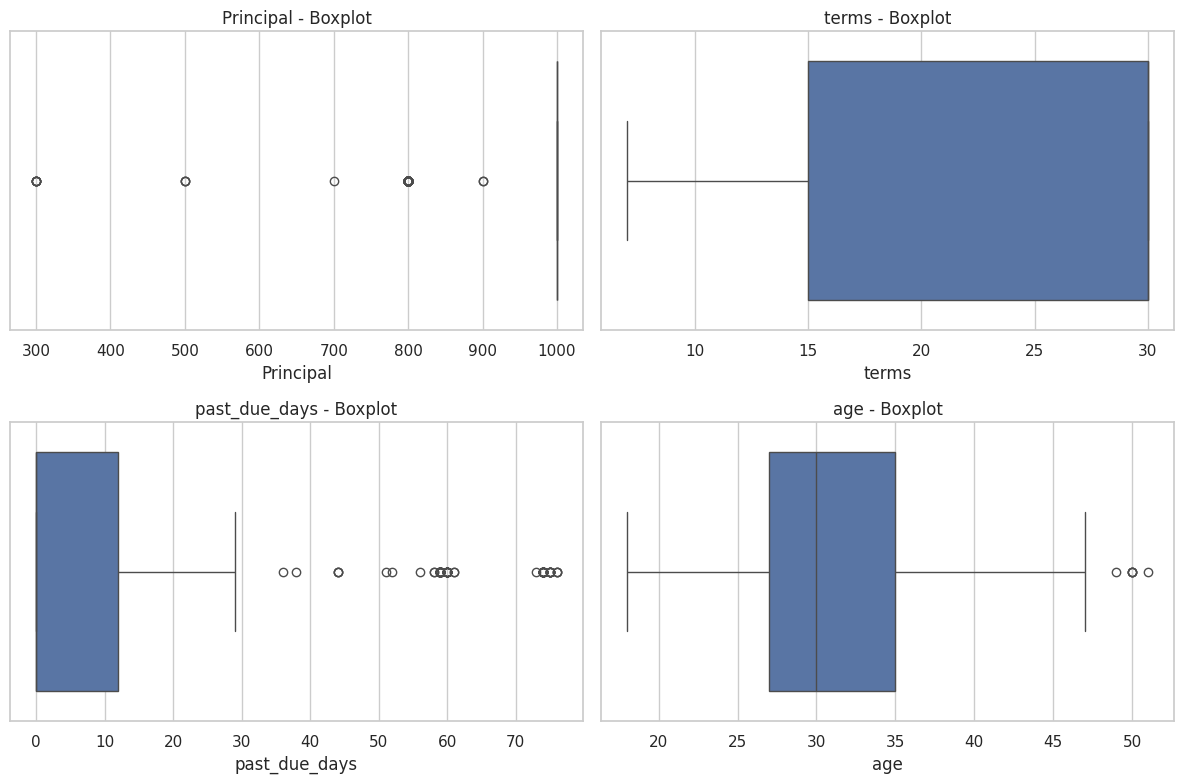

In [40]:
# Visualize distributions of all numerical features before outlier handling
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), ['Principal', 'terms', 'past_due_days', 'age']):
    sns.boxplot(x=df_clean[col], ax=ax)
    ax.set_title(f"{col} - Boxplot")

plt.tight_layout()
plt.show()


In [41]:
# IQR-based outlier detection for all numerical features
outlier_cols = ['Principal', 'terms', 'past_due_days', 'age']

for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)].shape[0]
    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Lower bound={lower:.2f}, Upper bound={upper:.2f}")
    print(f"  Number of outliers: {n_outliers}")



Principal:
  Q1=1000.00, Q3=1000.00, IQR=0.00
  Lower bound=1000.00, Upper bound=1000.00
  Number of outliers: 123

terms:
  Q1=15.00, Q3=30.00, IQR=15.00
  Lower bound=-7.50, Upper bound=52.50
  Number of outliers: 0

past_due_days:
  Q1=0.00, Q3=12.00, IQR=12.00
  Lower bound=-18.00, Upper bound=30.00
  Number of outliers: 101

age:
  Q1=27.00, Q3=35.00, IQR=8.00
  Lower bound=15.00, Upper bound=47.00
  Number of outliers: 6


Original shape: (500, 10)
After capping: (500, 10)


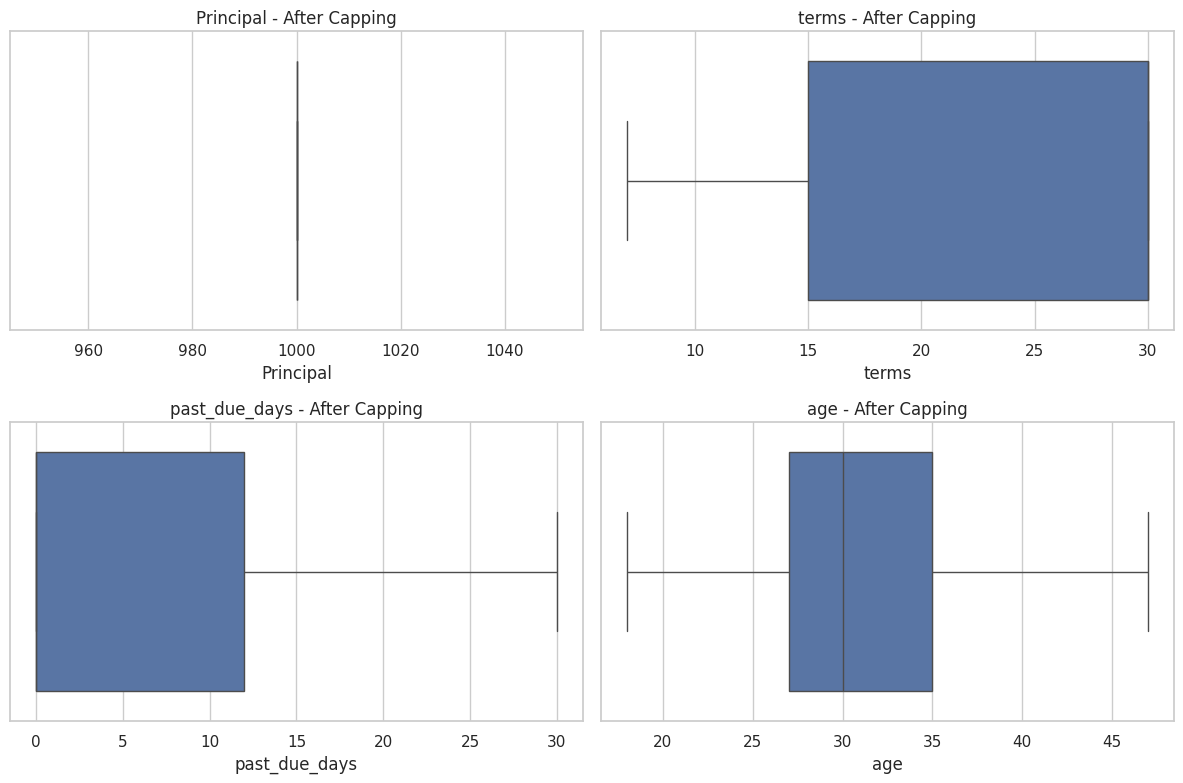

In [42]:
# Handle outliers using IQR capping (Winsorization)
df_no_outliers = df_clean.copy()

for col in outlier_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_no_outliers[col] = df_no_outliers[col].clip(lower, upper)

print("Original shape:", df_clean.shape)
print("After capping:", df_no_outliers.shape)

# Visualize after capping
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), outlier_cols):
    sns.boxplot(x=df_no_outliers[col], ax=ax)
    ax.set_title(f"{col} - After Capping")
plt.tight_layout()
plt.show()


## Task 4: Normalize Numerical Features Using Min-Max and Z-Score

In [43]:
num_features = ['Principal', 'terms', 'past_due_days', 'age']

# Show original values before scaling
print("Original stats:")
df_no_outliers[num_features].describe().round(2)


Original stats:


,Principal,terms,past_due_days,age
count,500.0,500.00,500.00,500.00
mean,1000.0,22.82,7.63,31.08
std,0.0,8.00,12.41,5.98
min,1000.0,7.00,0.00,18.00
25%,1000.0,15.00,0.00,27.00
50%,1000.0,30.00,0.00,30.00
75%,1000.0,30.00,12.00,35.00
max,1000.0,30.00,30.00,47.00


In [44]:
# --- Min-Max Normalization ---
minmax_scaler = MinMaxScaler()
df_minmax = df_no_outliers[num_features].copy()
df_minmax[num_features] = minmax_scaler.fit_transform(df_minmax)

print("After Min-Max Normalization (values in [0, 1]):")
df_minmax.describe().round(4)


After Min-Max Normalization (values in [0, 1]):


,Principal,terms,past_due_days,age
count,500.0,500.0000,500.0000,500.0000
mean,0.0,0.6880,0.2542,0.4510
std,0.0,0.3478,0.4136,0.2062
min,0.0,0.0000,0.0000,0.0000
25%,0.0,0.3478,0.0000,0.3103
50%,0.0,1.0000,0.0000,0.4138
75%,0.0,1.0000,0.4000,0.5862
max,0.0,1.0000,1.0000,1.0000


In [45]:
# --- Z-Score Standardization ---
std_scaler = StandardScaler()
df_zscore = df_no_outliers[num_features].copy()
df_zscore[num_features] = std_scaler.fit_transform(df_zscore)

print("After Z-Score Standardization (mean ≈ 0, std ≈ 1):")
df_zscore.describe().round(4)


After Z-Score Standardization (mean ≈ 0, std ≈ 1):


,Principal,terms,past_due_days,age
count,500.0,500.0000,500.0000,500.0000
mean,0.0,-0.0000,-0.0000,0.0000
std,0.0,1.0010,1.0010,1.0010
min,0.0,-1.9800,-0.6152,-2.1893
25%,0.0,-0.9790,-0.6152,-0.6829
50%,0.0,0.8979,-0.6152,-0.1808
75%,0.0,0.8979,0.3529,0.6561
max,0.0,0.8979,1.8051,2.6647


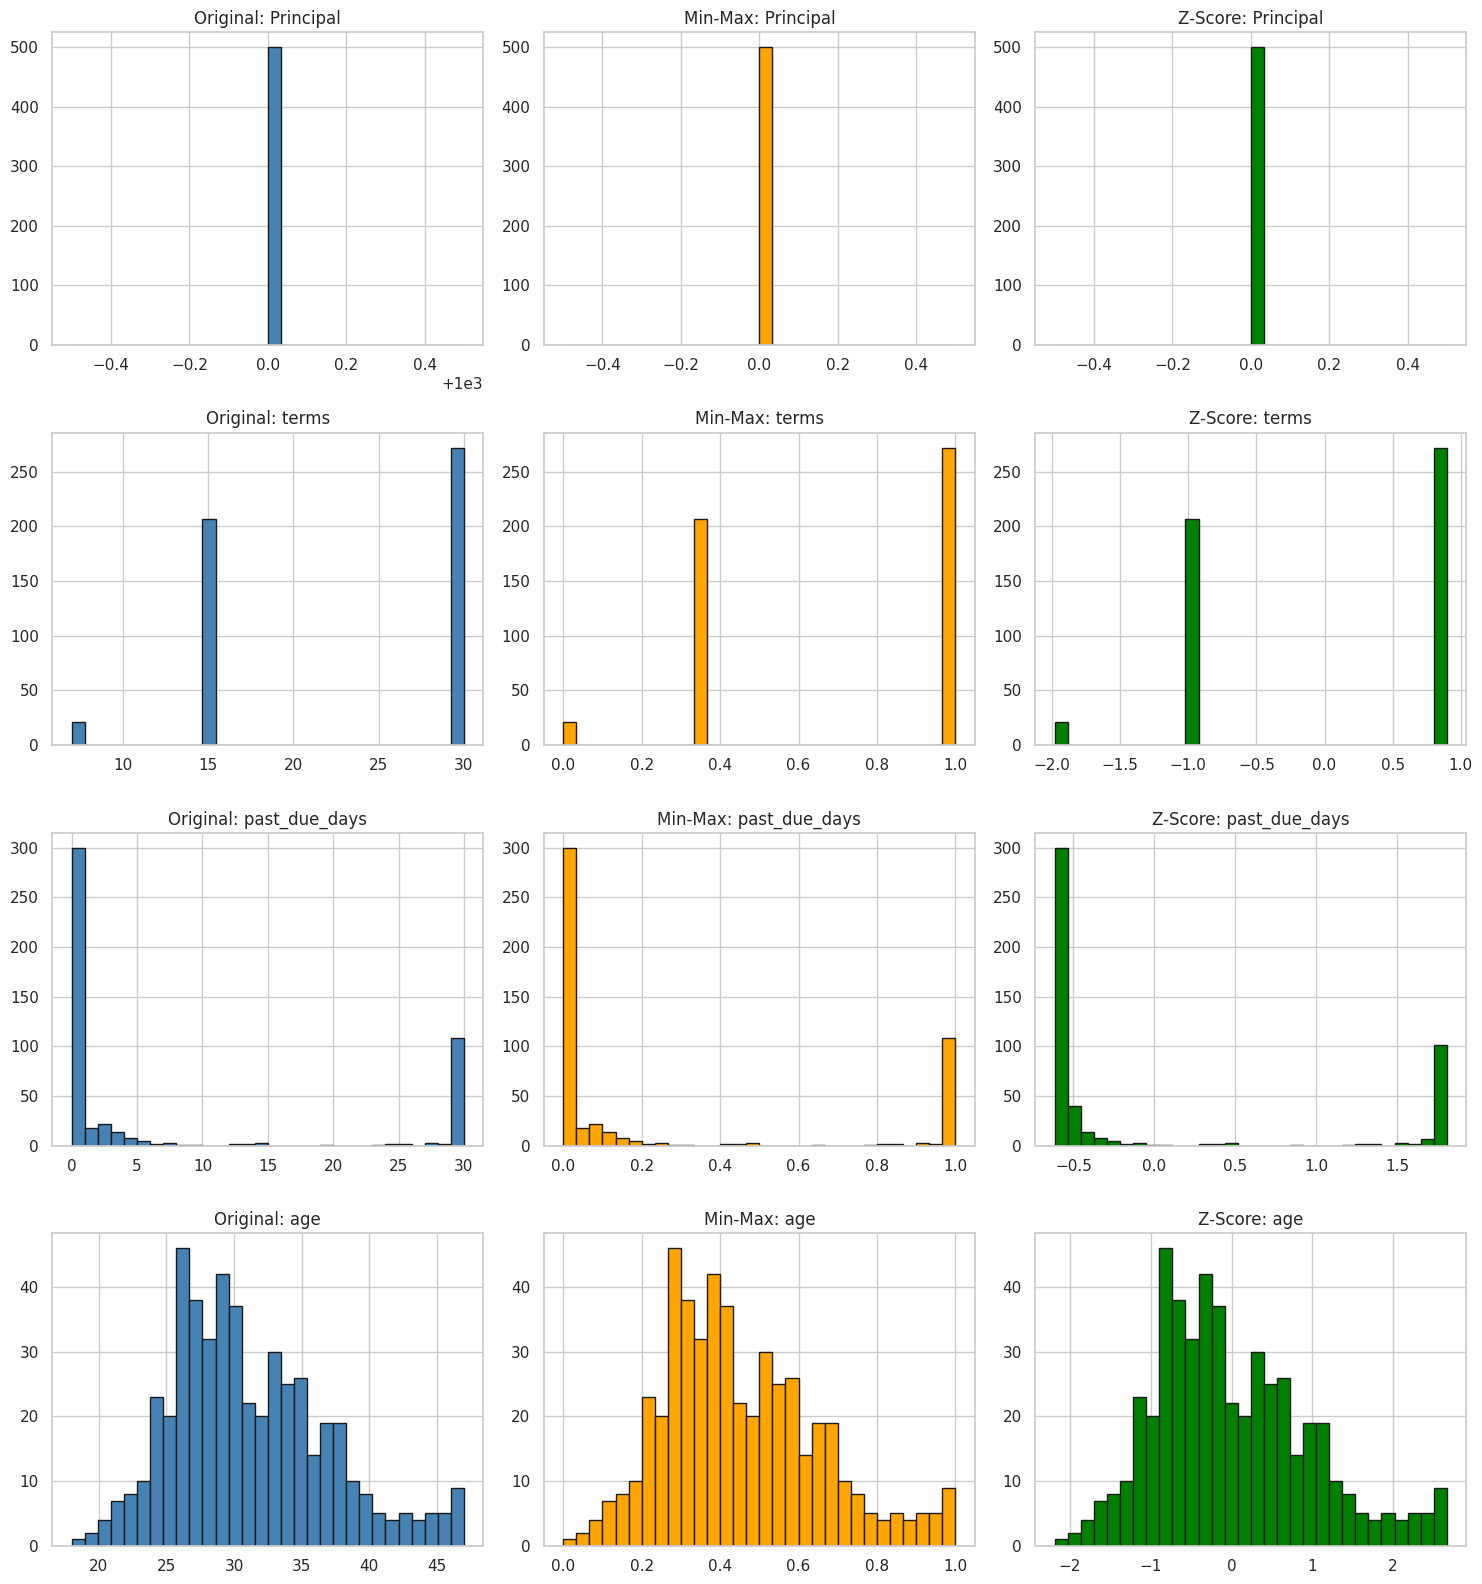

In [46]:
# Visual comparison: original vs Min-Max vs Z-Score for each numerical feature
fig, axes = plt.subplots(len(num_features), 3, figsize=(15, 4 * len(num_features)))

for i, col in enumerate(num_features):
    axes[i, 0].hist(df_no_outliers[col], bins=30, color='steelblue', edgecolor='k')
    axes[i, 0].set_title(f"Original: {col}")
    axes[i, 1].hist(df_minmax[col], bins=30, color='orange', edgecolor='k')
    axes[i, 1].set_title(f"Min-Max: {col}")
    axes[i, 2].hist(df_zscore[col], bins=30, color='green', edgecolor='k')
    axes[i, 2].set_title(f"Z-Score: {col}")

plt.tight_layout()

plt.show()

## Task 5: Apply PCA and Interpret Explained Variance

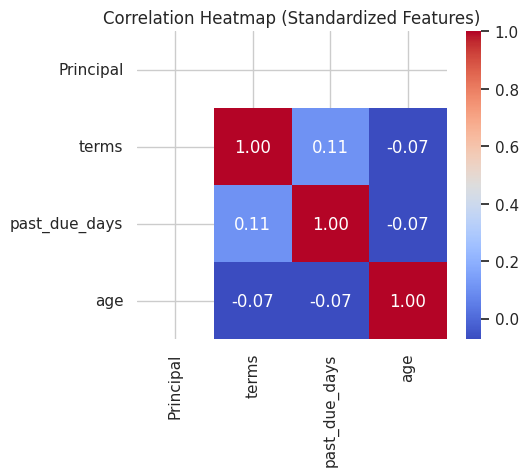

In [49]:
# Check correlation before PCA
plt.figure(figsize=(5, 4))
sns.heatmap(df_zscore.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Standardized Features)")
plt.show()


In [50]:
# Apply PCA with all 4 components to inspect explained variance
pca = PCA(n_components=4)
principal_components = pca.fit_transform(df_zscore)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained Variance Ratio per component:")
for i, (ev, cv) in enumerate(zip(explained, cumulative), 1):
    print(f"  PC{i}: {ev:.4f} ({ev*100:.2f}%)  |  Cumulative: {cv*100:.2f}%")


Explained Variance Ratio per component:
  PC1: 0.3889 (38.89%)  |  Cumulative: 38.89%
  PC2: 0.3131 (31.31%)  |  Cumulative: 70.20%
  PC3: 0.2980 (29.80%)  |  Cumulative: 100.00%
  PC4: 0.0000 (0.00%)  |  Cumulative: 100.00%


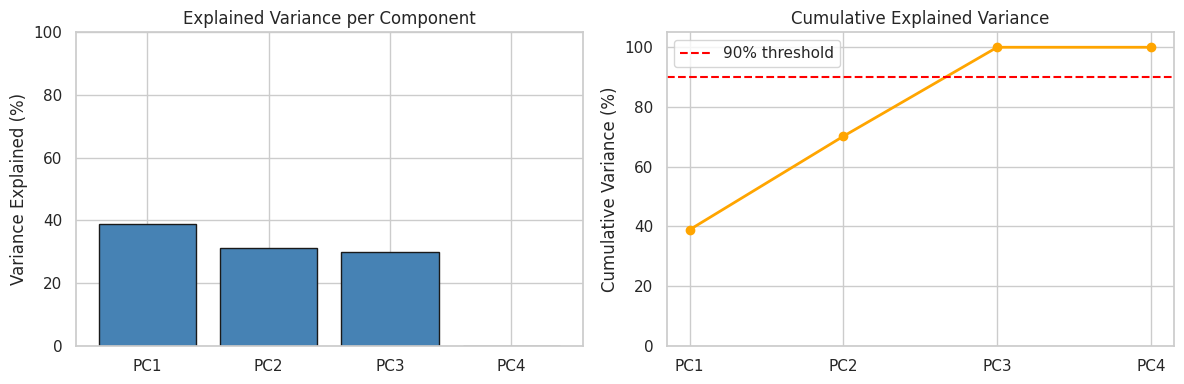

In [51]:
# Scree plot: visualize explained variance per component
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

components = [f'PC{i+1}' for i in range(len(explained))]

# Bar chart: individual variance
axes[0].bar(components, explained * 100, color='steelblue', edgecolor='k')
axes[0].set_title("Explained Variance per Component")
axes[0].set_ylabel("Variance Explained (%)")
axes[0].set_ylim(0, 100)

# Line chart: cumulative variance
axes[1].plot(components, cumulative * 100, marker='o', color='orange', linewidth=2)
axes[1].axhline(y=90, color='red', linestyle='--', label='90% threshold')
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_ylabel("Cumulative Variance (%)")
axes[1].set_ylim(0, 105)
axes[1].legend()

plt.tight_layout()
plt.show()


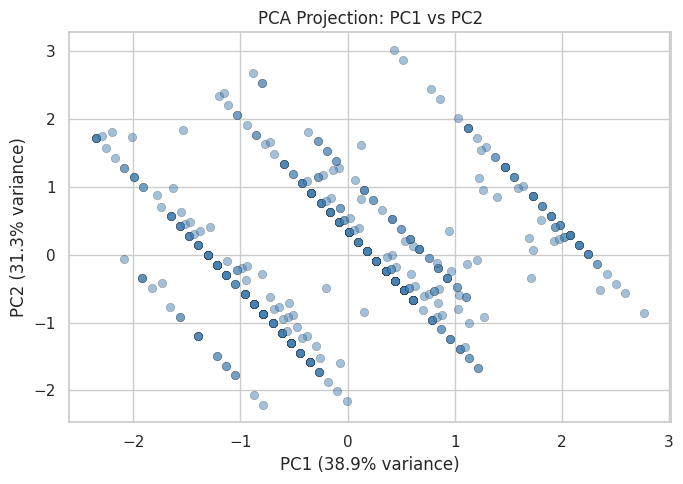

In [52]:
# 2D PCA projection: scatter plot of PC1 vs PC2
plt.figure(figsize=(7, 5))
plt.scatter(principal_components[:, 0], principal_components[:, 1],
            alpha=0.5, edgecolors='k', linewidths=0.3, color='steelblue')
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")
plt.title("PCA Projection: PC1 vs PC2")
plt.tight_layout()
plt.show()
